In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.3: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,

)

In [4]:
from datasets import load_dataset
dataset = load_dataset("Raja6922/navarasa_Balanced", split = "train")

README.md:   0%|          | 0.00/473 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/417M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/425M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/182M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6951 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/773 [00:00<?, ? examples/s]

In [5]:
dataset

Dataset({
    features: ['image', 'navarasa', 'text'],
    num_rows: 6951
})

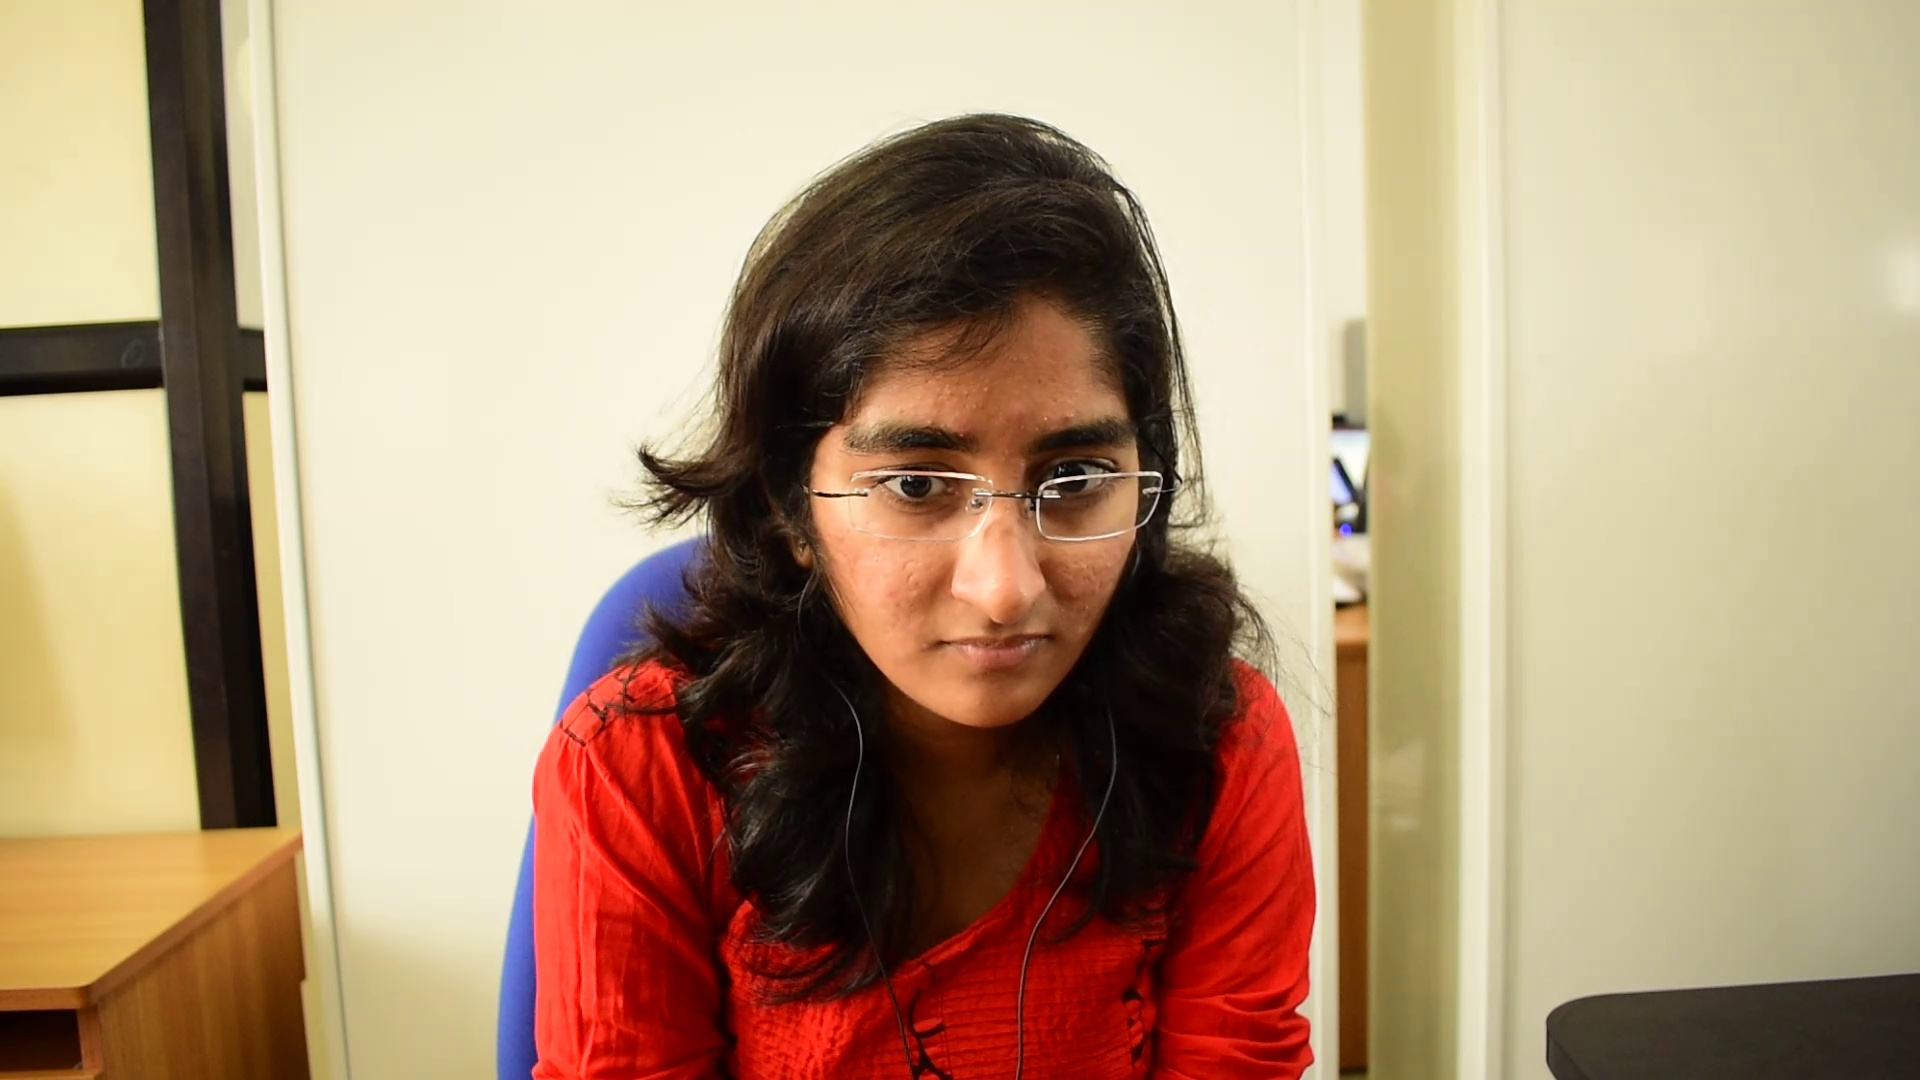

In [51]:
dataset[4112]["image"]

In [52]:
dataset[4112]["text"]

'The subject exhibiting Bhayanaka, with a young woman wearing glasses sits at a desk , conveying the emotional essence of Bhayanaka.'

In [8]:
instruction = (
    "You are an expert in Navarasa emotion recognition.\n"
    "Navarasa consists of the following nine emotions:\n"
    "1. Shringara (love)\n"
    "2. Hasya (laughter)\n"
    "3. Karuna (compassion)\n"
    "4. Raudra (anger)\n"
    "5. Veera (heroism)\n"
    "6. Bhayanaka (fear)\n"
    "7. Bibhatsa (disgust)\n"
    "8. Adbhuta (wonder)\n"
    "9. Shanta (peace)\n\n"
    "Identify the dominant Navarasa emotion shown by the person in the image.\n"
    "Choose ONLY ONE emotion from the above list.\n"
    "Respond in EXACTLY this format and nothing else:\n"
    'The person in the image is showing the emotion "<EMOTION>".'
)


def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [9]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [10]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are an expert in Navarasa emotion recognition.\nNavarasa consists of the following nine emotions:\n1. Shringara (love)\n2. Hasya (laughter)\n3. Karuna (compassion)\n4. Raudra (anger)\n5. Veera (heroism)\n6. Bhayanaka (fear)\n7. Bibhatsa (disgust)\n8. Adbhuta (wonder)\n9. Shanta (peace)\n\nIdentify the dominant Navarasa emotion shown by the person in the image.\nChoose ONLY ONE emotion from the above list.\nRespond in EXACTLY this format and nothing else:\nThe person in the image is showing the emotion "<EMOTION>".'},
    {'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1920x1080>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'The subject exhibiting Hasya, with a woman wearing glasses and a black top smiles , conveying the emotional essence of Hasya.'}]}]}

Let's first see before we do any finetuning what the model outputs for the first example!

In [53]:
FastVisionModel.for_inference(model)

image = dataset[4112]["image"]
instruction = (
    "You are an expert in Navarasa emotion recognition.\n"
    "Navarasa consists of the following nine emotions:\n"
    "1. Shringara (love)\n"
    "2. Hasya (laughter)\n"
    "3. Karuna (compassion)\n"
    "4. Raudra (anger)\n"
    "5. Veera (heroism)\n"
    "6. Bhayanaka (fear)\n"
    "7. Bibhatsa (disgust)\n"
    "8. Adbhuta (wonder)\n"
    "9. Shanta (peace)\n\n"
    "Identify the dominant Navarasa emotion shown by the person in the image.\n"
    "Choose ONLY ONE emotion from the above list.\n"
    "Respond in EXACTLY this format and nothing else:\n"
    'The person in the image is showing the emotion "<EMOTION>".'
)

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

The subject exhibiting Shantha, with a young girl wearing headphones and sitting in front of a computer , conveying the emotional essence of Shantha.<|im_end|>


In [14]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 500,
        # num_train_epochs = 1,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [15]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-80GB. Max memory = 79.318 GB.
8.326 GB of memory reserved.


In [16]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,951 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,2.934900
2,2.939400
3,2.813700
4,2.642700
5,2.299100
6,1.948700
7,1.590700
8,1.419400
9,1.206900
10,1.044200


In [17]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1934.9319 seconds used for training.
32.25 minutes used for training.
Peak reserved memory = 8.625 GB.
Peak reserved memory for training = 0.299 GB.
Peak reserved memory % of max memory = 10.874 %.
Peak reserved memory for training % of max memory = 0.377 %.


In [34]:
FastVisionModel.for_inference(model)

image = dataset[4112]["image"]
instruction = (
    "You are an expert in Navarasa emotion recognition.\n"
    "Navarasa consists of the following nine emotions:\n"
    "1. Shringara (love)\n"
    "2. Hasya (laughter)\n"
    "3. Karuna (compassion)\n"
    "4. Raudra (anger)\n"
    "5. Veera (heroism)\n"
    "6. Bhayanaka (fear)\n"
    "7. Bibhatsa (disgust)\n"
    "8. Adbhuta (wonder)\n"
    "9. Shanta (peace)\n\n"
    "Identify the dominant Navarasa emotion shown by the person in the image.\n"
    "Choose ONLY ONE emotion from the above list.\n"
    "Respond in EXACTLY this format and nothing else:\n"
    'The person in the image is showing the emotion "<EMOTION>".'
)
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

The subject exhibiting Bhayanaka, with a woman sitting in front of a white wall , conveying the emotional essence of Bhayanaka.<|im_end|>


In [ ]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")
model.push_to_hub("Raja6922/Qwen3VL_8B", token = "hf")
tokenizer.push_to_hub("Raja6922/Qwen3VL_8B", token = "hf")

README.md:   0%|          | 0.00/586 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 69.1kB /  205MB            

Saved model to https://huggingface.co/Raja6922/Qwen3VL_8B


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mplohrueib/tokenizer.json:   0%|          | 28.6kB / 11.4MB            